# Mask vs No-Mask Sweep Analysis

Compares models trained with input loss masking vs without, across:
- `prop` ∈ {0.01, 0.1, 0.5, 0.9, 0.99}
- `tf` ∈ {0.01, 0.1, 0.5, 0.9, 0.99}
- `level` ∈ {tense_separate, full_sequence}
- `mask` ∈ {mask, nomask}

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path("/n/netscratch/dam_lab/Lab/drooryck/codeswitching-llms/"
            "april_exp/trans_conj/results/mask_sweep_apr14/runs")

PROPS = [0.01, 0.1, 0.5, 0.9, 0.99]
TFS = [0.01, 0.1, 0.5, 0.9, 0.99]
LEVELS = ["tense_separate", "full_sequence"]
MODES = ["mask", "nomask"]

records = []
missing = []
for mode in MODES:
    for level in LEVELS:
        for prop in PROPS:
            for tf in TFS:
                name = f"{mode}_{level}_prop{prop}_tf{tf}_run01"
                d = ROOT / name
                metrics_file = d / "eval_sample_metrics.csv"
                if not metrics_file.exists():
                    missing.append(name)
                    continue
                df = pd.read_csv(metrics_file)
                df["mode"] = mode
                df["level"] = level
                df["prop"] = prop
                df["tf"] = tf
                records.append(df)

if missing:
    print(f"Missing {len(missing)}/{len(MODES)*len(LEVELS)*len(PROPS)*len(TFS)} runs:")
    for m in missing[:10]:
        print(f"  {m}")
    if len(missing) > 10:
        print(f"  ... and {len(missing)-10} more")

if records:
    all_df = pd.concat(records, ignore_index=True)
    all_df = all_df.rename(columns={
        "nl_morphology": "nl_lexical", "fr_morphology": "fr_lexical"})
    print(f"Loaded {len(records)} runs, {len(all_df)} total eval rows")
    print(f"Columns: {list(all_df.columns)}")
else:
    print("No runs found yet — have the SLURM jobs completed?")

Loaded 100 runs, 3610 total eval rows
Columns: ['step', 'fr_lexical', 'fr_syntax', 'fr_conformity', 'fr_exact_match', 'nl_lexical', 'nl_syntax', 'nl_conformity', 'nl_exact_match', 'mode', 'level', 'prop', 'tf', 'fr_pos_validity', 'fr_pos_coverage', 'nl_pos_validity', 'nl_pos_coverage']


In [2]:
# Final-step metrics for every run
final = all_df.loc[all_df.groupby(["mode", "level", "prop", "tf"]).step.idxmax()].copy()
print(f"{len(final)} runs at final step")
final[["mode", "level", "prop", "tf", "nl_lexical", "fr_lexical",
       "nl_exact_match", "fr_exact_match"]].sort_values(
    ["level", "prop", "tf", "mode"])

100 runs at final step


,mode,level,prop,tf,nl_lexical,fr_lexical,nl_exact_match,fr_exact_match
1099,mask,full_sequence,0.01,0.01,0.000000,1.000000,1.000000,1.000000
2904,nomask,full_sequence,0.01,0.01,0.000000,1.000000,1.000000,1.000000
1120,mask,full_sequence,0.01,0.10,0.000000,1.000000,1.000000,1.000000
2925,nomask,full_sequence,0.01,0.10,0.000000,1.000000,1.000000,1.000000
1147,mask,full_sequence,0.01,0.50,0.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...
2742,nomask,tense_separate,0.99,0.50,0.000000,1.000000,0.079460,0.967543
1000,mask,tense_separate,0.99,0.90,0.000000,1.000000,0.994003,1.000000
2805,nomask,tense_separate,0.99,0.90,0.433340,0.996394,0.000000,0.032457
1079,mask,tense_separate,0.99,0.99,0.000000,1.000000,0.020990,1.000000


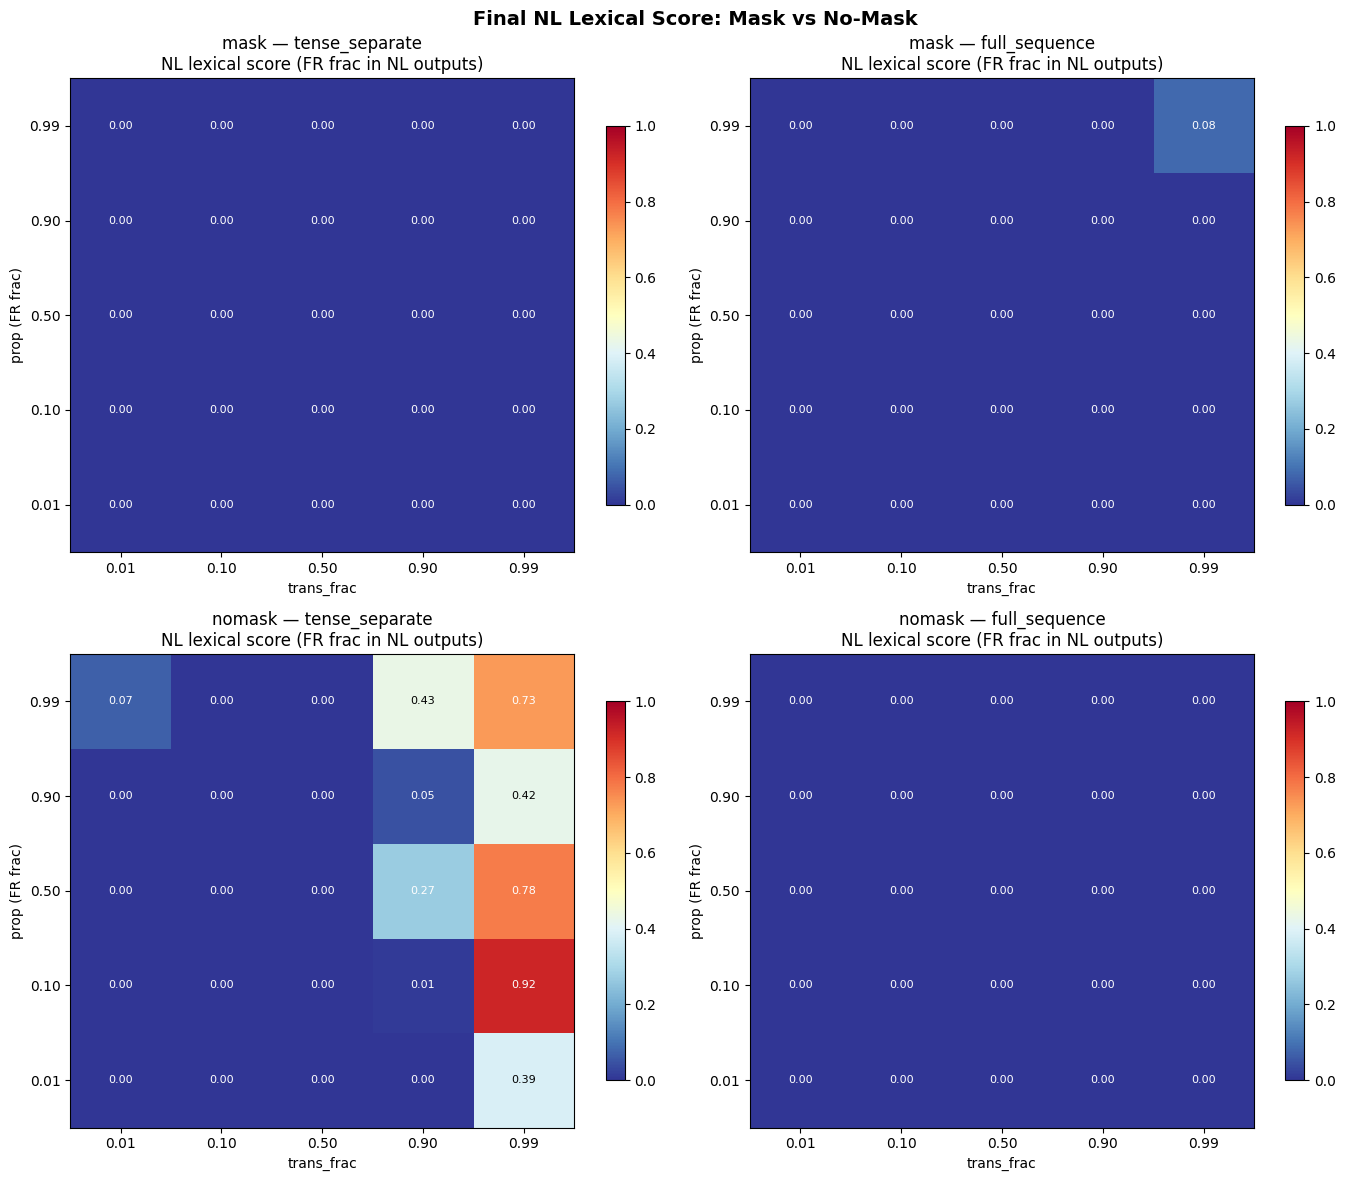

In [3]:
# Heatmap: final NL lexical score (mask vs nomask) for each (prop, tf)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for col_idx, level in enumerate(LEVELS):
    for row_idx, mode in enumerate(MODES):
        ax = axes[row_idx, col_idx]
        subset = final[(final.level == level) & (final["mode"] == mode)]
        pivot = subset.pivot_table(index="prop", columns="tf",
                                   values="nl_lexical", aggfunc="mean")
        im = ax.imshow(pivot.values, cmap="RdYlBu_r", vmin=0, vmax=1,
                       aspect="auto", origin="lower")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"{v:.2f}" for v in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{v:.2f}" for v in pivot.index])
        ax.set_xlabel("trans_frac")
        ax.set_ylabel("prop (FR frac)")
        ax.set_title(f"{mode} — {level}\nNL lexical score (FR frac in NL outputs)")
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                            fontsize=8, color="black" if 0.3 < val < 0.7 else "white")
        plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle("Final NL Lexical Score: Mask vs No-Mask", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

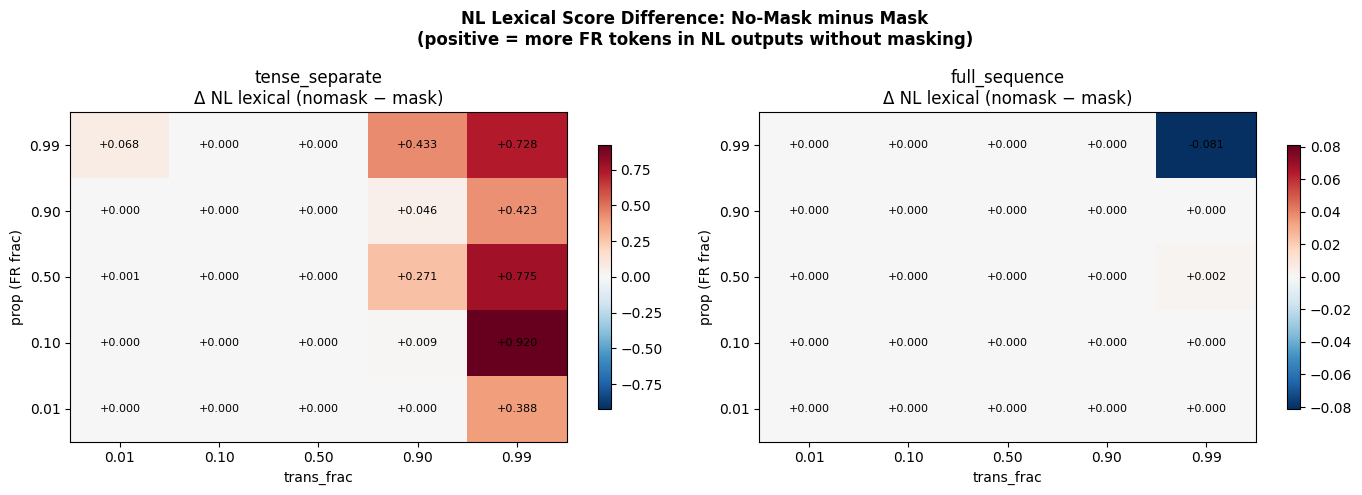

In [4]:
# Difference heatmap: nomask - mask
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col_idx, level in enumerate(LEVELS):
    ax = axes[col_idx]
    mask_piv = final[(final.level == level) & (final["mode"] == "mask")].pivot_table(
        index="prop", columns="tf", values="nl_lexical", aggfunc="mean")
    nomask_piv = final[(final.level == level) & (final["mode"] == "nomask")].pivot_table(
        index="prop", columns="tf", values="nl_lexical", aggfunc="mean")
    diff = nomask_piv - mask_piv
    vmax = max(abs(diff.values[~np.isnan(diff.values)].min()),
              abs(diff.values[~np.isnan(diff.values)].max()), 0.01)
    im = ax.imshow(diff.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   aspect="auto", origin="lower")
    ax.set_xticks(range(len(diff.columns)))
    ax.set_xticklabels([f"{v:.2f}" for v in diff.columns])
    ax.set_yticks(range(len(diff.index)))
    ax.set_yticklabels([f"{v:.2f}" for v in diff.index])
    ax.set_xlabel("trans_frac")
    ax.set_ylabel("prop (FR frac)")
    ax.set_title(f"{level}\nΔ NL lexical (nomask − mask)")
    for i in range(len(diff.index)):
        for j in range(len(diff.columns)):
            val = diff.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:+.3f}", ha="center", va="center",
                        fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle("NL Lexical Score Difference: No-Mask minus Mask\n(positive = more FR tokens in NL outputs without masking)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

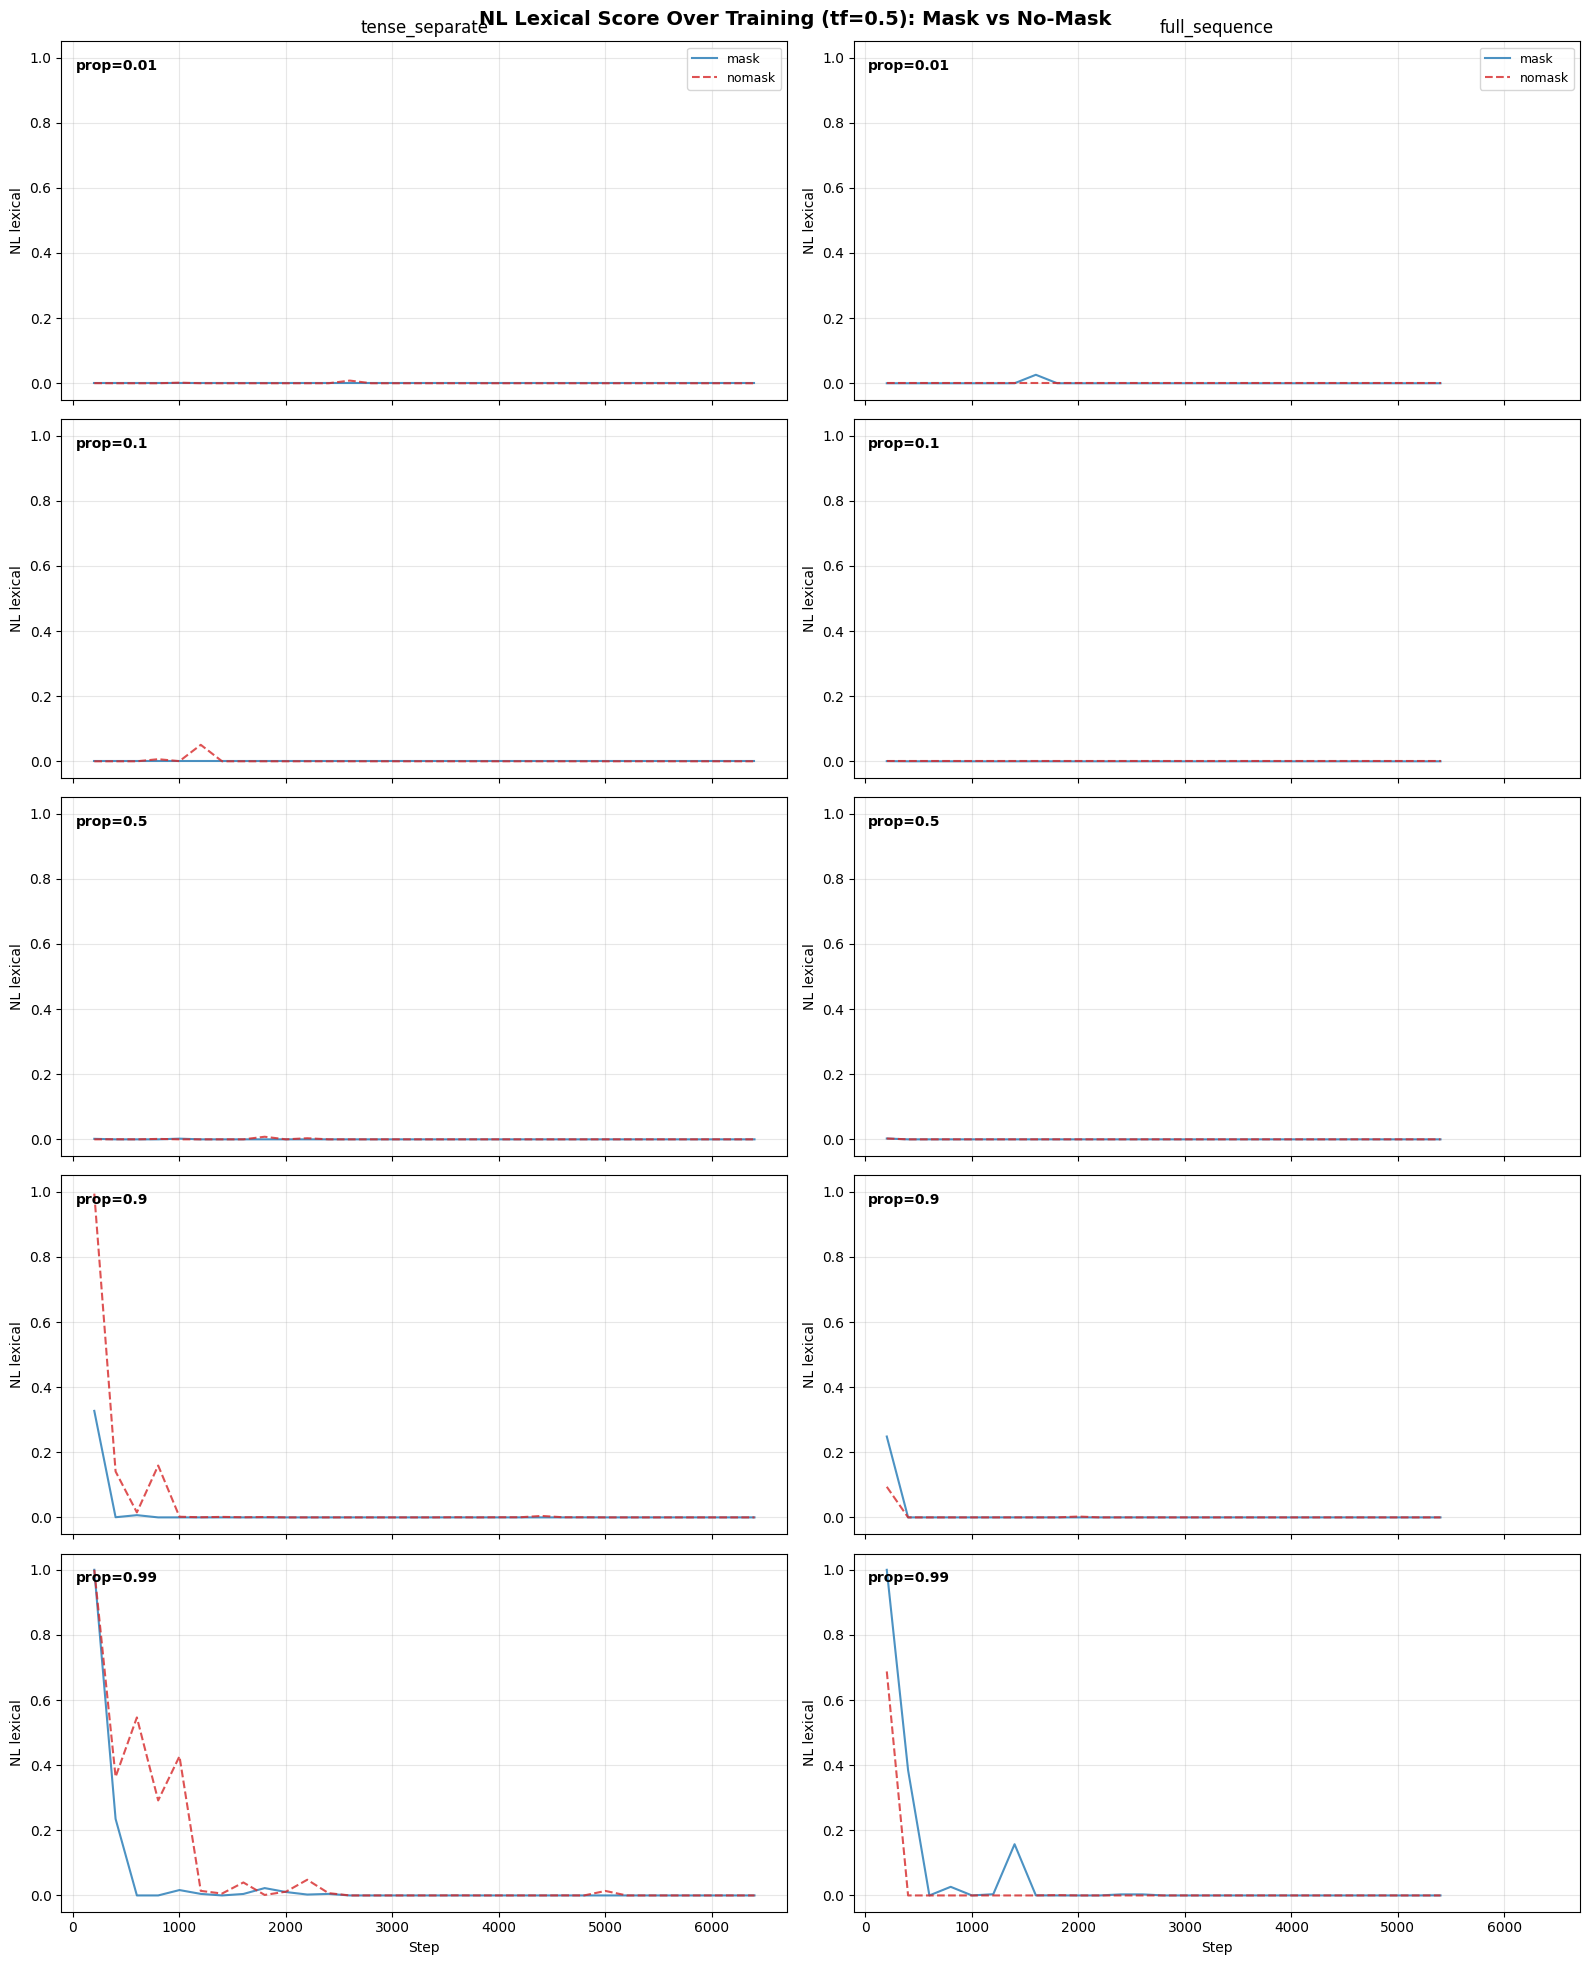

In [5]:
# Time-series comparison at fixed tf=0.5 across props
fig, axes = plt.subplots(len(PROPS), 2, figsize=(16, 4*len(PROPS)), sharex=True)

for row, prop in enumerate(PROPS):
    for col, level in enumerate(LEVELS):
        ax = axes[row, col]
        for mode, color, ls in [("mask", "tab:blue", "-"), ("nomask", "tab:red", "--")]:
            sub = all_df[(all_df.level == level) & (all_df.prop == prop) &
                         (all_df.tf == 0.5) & (all_df["mode"] == mode)]
            if len(sub) > 0:
                ax.plot(sub.step, sub.nl_lexical, color=color, ls=ls,
                        linewidth=1.5, label=mode, alpha=0.8)
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel("NL lexical")
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(f"{level}", fontsize=12)
            ax.legend(fontsize=9)
        ax.text(0.02, 0.95, f"prop={prop}", transform=ax.transAxes,
                fontsize=10, va="top", fontweight="bold")
        if row == len(PROPS) - 1:
            ax.set_xlabel("Step")

fig.suptitle("NL Lexical Score Over Training (tf=0.5): Mask vs No-Mask",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

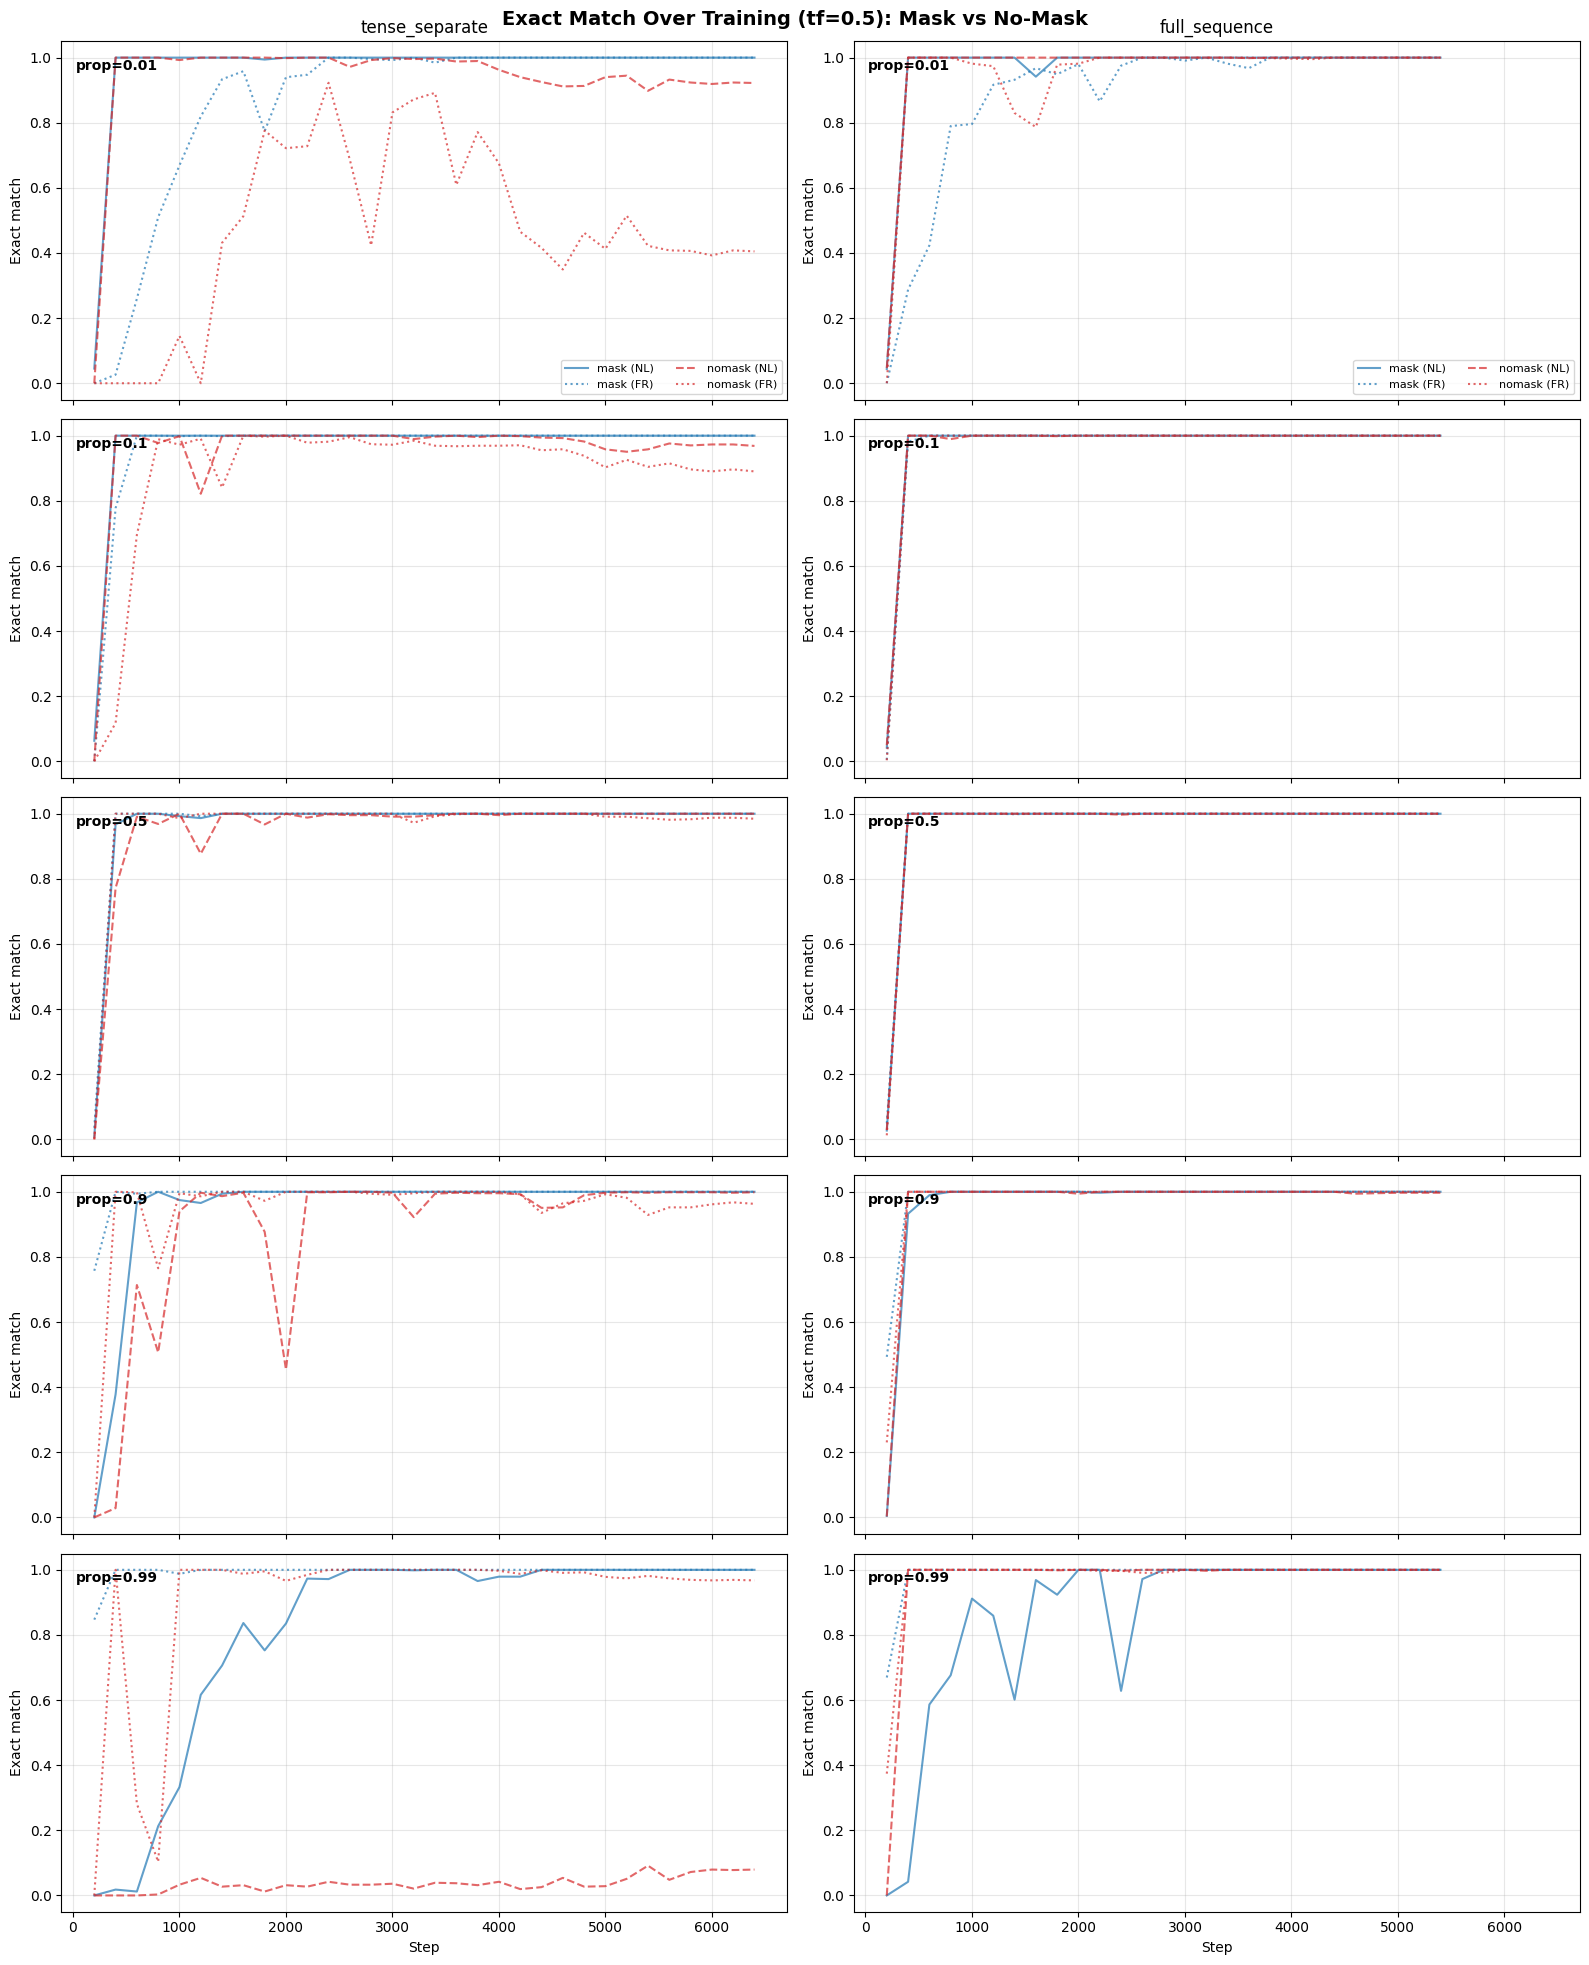

In [6]:
# Same time-series but for exact match
fig, axes = plt.subplots(len(PROPS), 2, figsize=(16, 4*len(PROPS)), sharex=True)

for row, prop in enumerate(PROPS):
    for col, level in enumerate(LEVELS):
        ax = axes[row, col]
        for mode, color, ls in [("mask", "tab:blue", "-"), ("nomask", "tab:red", "--")]:
            sub = all_df[(all_df.level == level) & (all_df.prop == prop) &
                         (all_df.tf == 0.5) & (all_df["mode"] == mode)]
            if len(sub) > 0:
                ax.plot(sub.step, sub.nl_exact_match, color=color, ls=ls,
                        linewidth=1.5, label=f"{mode} (NL)", alpha=0.7)
                ax.plot(sub.step, sub.fr_exact_match, color=color, ls=":",
                        linewidth=1.5, label=f"{mode} (FR)", alpha=0.7)
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel("Exact match")
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(f"{level}", fontsize=12)
            ax.legend(fontsize=8, ncol=2)
        ax.text(0.02, 0.95, f"prop={prop}", transform=ax.transAxes,
                fontsize=10, va="top", fontweight="bold")
        if row == len(PROPS) - 1:
            ax.set_xlabel("Step")

fig.suptitle("Exact Match Over Training (tf=0.5): Mask vs No-Mask",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

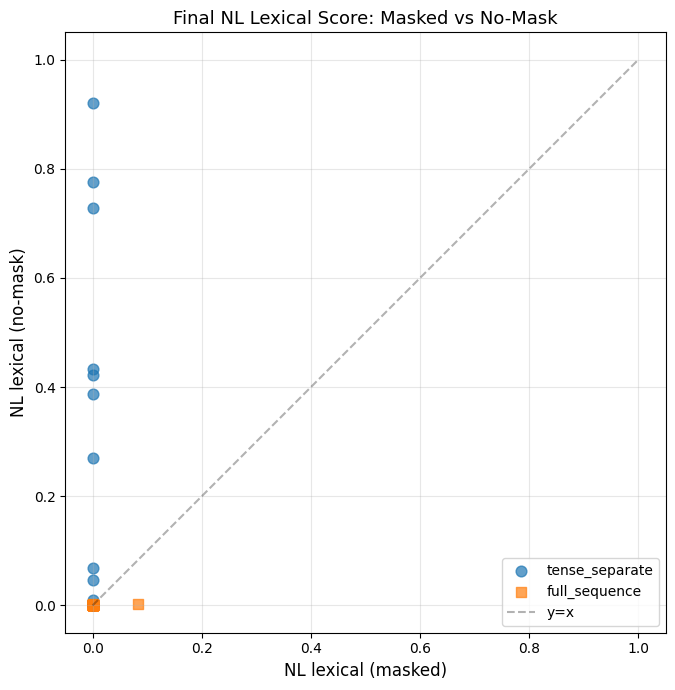

In [7]:
# Scatter: mask vs nomask final NL lexical score across all (prop, tf, level) combos
mask_final = final[final["mode"] == "mask"].set_index(["level", "prop", "tf"])
nomask_final = final[final["mode"] == "nomask"].set_index(["level", "prop", "tf"])
joined = mask_final[["nl_lexical"]].rename(columns={"nl_lexical": "mask"}).join(
    nomask_final[["nl_lexical"]].rename(columns={"nl_lexical": "nomask"}),
    how="inner")

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for level, marker in [("tense_separate", "o"), ("full_sequence", "s")]:
    sub = joined.loc[level]
    ax.scatter(sub["mask"], sub["nomask"], marker=marker, s=60, alpha=0.7, label=level)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label="y=x")
ax.set_xlabel("NL lexical (masked)", fontsize=12)
ax.set_ylabel("NL lexical (no-mask)", fontsize=12)
ax.set_title("Final NL Lexical Score: Masked vs No-Mask", fontsize=13)
ax.legend()
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# ── Interactive prediction browser ──
# Change these variables to explore different runs:
MODE = "nomask"          # "mask" or "nomask"
LEVEL = "tense_separate" # "tense_separate" or "full_sequence"
PROP = 0.5               # 0.01, 0.1, 0.5, 0.9, 0.99
TF = 0.99                # 0.01, 0.1, 0.5, 0.9, 0.99
LANG = None              # "fr", "nl", or None for both
N = 20                   # number of rows to show

run_name = f"{MODE}_{LEVEL}_prop{PROP}_tf{TF}_run01"
pred_path = ROOT / run_name / "test_predictions.csv"

if pred_path.exists():
    preds = pd.read_csv(pred_path)
    if LANG:
        preds = preds[preds.language == LANG]
    preds["match"] = preds.prediction == preds.gold

    n_total = len(preds)
    n_correct = preds["match"].sum()
    print(f"Run: {run_name}")
    print(f"Exact match: {n_correct}/{n_total} ({n_correct/n_total:.1%})")
    if LANG:
        print(f"Filtered to: {LANG}")
    print()

    # show mismatches first, then matches
    display_df = pd.concat([
        preds[~preds["match"]].head(N),
        preds[preds["match"]].head(max(0, N - (~preds["match"]).sum()))
    ]).head(N)

    # color-code: bold the prediction column for mismatches
    def highlight(row):
        if not row["match"]:
            return [""] * len(row.index[:-1]) + [""] if "match" not in row.index else \
                   ["background-color: #ffcccc" if c == "prediction" else "" for c in row.index]
        return [""] * len(row.index)

    styled = display_df[["language", "input", "gold", "prediction", "match"]].style.apply(
        highlight, axis=1)
    display(styled)
else:
    print(f"Not found: {pred_path}")

Run: nomask_tense_separate_prop0.5_tf0.99_run01
Exact match: 0/118238 (0.0%)



,language,input,gold,prediction,match
0,fr,le garçon perd les poissons,le garçon a perdu les poissons,de de les de les de vissen,False
1,nl,de krabben slaan de olifanten,de krabben hebben de olifanten geslagen,de le les les éléphants,False
2,fr,le enfant observe le ennemi,le enfant a observé le ennemi,de de de de le de vijand,False
3,nl,de hond mag de aap,de hond heeft de aap gemogen,de le le le uilen le singe,False
4,nl,de vis geeft de uilen,de vis heeft de uilen gegeven,de les de les uilen,False
5,fr,le loup sauve le tortue,le loup a sauvé le tortue,de de de de le de schildpad,False
6,fr,les amis enseignent les corbeaux,les amis ont enseigné les corbeaux,de de de de kraaien,False
7,fr,les hommes observent les lézards,les hommes ont observé les lézards,de de les de les de hagedissen,False
8,nl,de adelaren luisteren de hagedis,de adelaren hebben de hagedis geluisterd,de les le le lézard,False
9,nl,de herten nemen de haaien,de herten hebben de haaien genomen,de le les les requins,False


In [9]:
# ── Side-by-side mask vs nomask comparison ──
# Change these to explore:
LEVEL_CMP = "tense_separate"  # "tense_separate" or "full_sequence"
PROP_CMP = 0.5                # 0.01, 0.1, 0.5, 0.9, 0.99
TF_CMP = 0.99                 # 0.01, 0.1, 0.5, 0.9, 0.99
LANG_CMP = "nl"               # "fr", "nl", or None for both
N_CMP = 15

mask_path = ROOT / f"mask_{LEVEL_CMP}_prop{PROP_CMP}_tf{TF_CMP}_run01" / "test_predictions.csv"
nomask_path = ROOT / f"nomask_{LEVEL_CMP}_prop{PROP_CMP}_tf{TF_CMP}_run01" / "test_predictions.csv"

if mask_path.exists() and nomask_path.exists():
    mp = pd.read_csv(mask_path)
    np_ = pd.read_csv(nomask_path)
    if LANG_CMP:
        mp = mp[mp.language == LANG_CMP].reset_index(drop=True)
        np_ = np_[np_.language == LANG_CMP].reset_index(drop=True)

    cmp = mp[["language", "input", "gold"]].copy()
    cmp["mask_pred"] = mp["prediction"]
    cmp["nomask_pred"] = np_["prediction"]
    cmp["mask_ok"] = mp["prediction"] == mp["gold"]
    cmp["nomask_ok"] = np_["prediction"] == np_["gold"]

    mask_em = cmp["mask_ok"].mean()
    nomask_em = cmp["nomask_ok"].mean()
    print(f"Level={LEVEL_CMP}  prop={PROP_CMP}  tf={TF_CMP}  lang={LANG_CMP or 'all'}")
    print(f"Mask EM: {mask_em:.1%}  |  No-mask EM: {nomask_em:.1%}")
    print()

    # show rows where they differ first
    differ = cmp[cmp["mask_pred"] != cmp["nomask_pred"]]
    same = cmp[cmp["mask_pred"] == cmp["nomask_pred"]]
    show = pd.concat([differ.head(N_CMP), same.head(max(0, N_CMP - len(differ)))]).head(N_CMP)

    def highlight_cmp(row):
        styles = [""] * len(row.index)
        cols = list(row.index)
        if "mask_ok" in cols and not row["mask_ok"]:
            styles[cols.index("mask_pred")] = "background-color: #ffcccc"
        if "nomask_ok" in cols and not row["nomask_ok"]:
            styles[cols.index("nomask_pred")] = "background-color: #ffcccc"
        return styles

    display(show[["language", "input", "gold", "mask_pred", "nomask_pred",
                  "mask_ok", "nomask_ok"]].style.apply(highlight_cmp, axis=1))
else:
    print(f"Missing: {mask_path.exists()=} {nomask_path.exists()=}")

Level=tense_separate  prop=0.5  tf=0.99  lang=nl
Mask EM: 100.0%  |  No-mask EM: 0.0%



,language,input,gold,mask_pred,nomask_pred,mask_ok,nomask_ok
0,nl,de krabben slaan de olifanten,de krabben hebben de olifanten geslagen,de krabben hebben de olifanten geslagen,de le les les éléphants,True,False
1,nl,de hond mag de aap,de hond heeft de aap gemogen,de hond heeft de aap gemogen,de le le le uilen le singe,True,False
2,nl,de vis geeft de uilen,de vis heeft de uilen gegeven,de vis heeft de uilen gegeven,de les de les uilen,True,False
3,nl,de adelaren luisteren de hagedis,de adelaren hebben de hagedis geluisterd,de adelaren hebben de hagedis geluisterd,de les le le lézard,True,False
4,nl,de herten nemen de haaien,de herten hebben de haaien genomen,de herten hebben de haaien genomen,de le les les requins,True,False
5,nl,de schildpad slaat de paarden,de schildpad heeft de paarden geslagen,de schildpad heeft de paarden geslagen,de le le les chevaux,True,False
6,nl,de schaap beschermt de kinderen,de schaap heeft de kinderen beschermd,de schaap heeft de kinderen beschermd,de les les les enfants,True,False
7,nl,de vijanden volgen de eenden,de vijanden hebben de eenden gevolgd,de vijanden hebben de eenden gevolgd,de le les les eenden,True,False
8,nl,de jongen observeert de konijn,de jongen heeft de konijn geobserveerd,de jongen heeft de konijn geobserveerd,de le le le les le lapin,True,False
9,nl,de bijen vallen de geit,de bijen hebben de geit aangevallen,de bijen hebben de geit aangevallen,de les le le chèvre,True,False
